**MetaLearner v1.1 — Clean Colab Setup**

We will do this in 6 clean stages:

1.   Install + imports.
2.   Load dataset (TinyStories subset).
3. Load GPT-2.
4. Define logging utilities.
5. Run multi-regime experiments.
6. Merge logs.


# we train v1.1.





In [1]:
!pip install datasets transformers accelerate -q

import torch
import math
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    DataCollatorForLanguageModeling
)
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [2]:
dataset = load_dataset(
    "roneneldan/TinyStories",
    split={
        "train": "train[:5%]",
        "validation": "validation[:5%]"
    }
)

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 105986
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1100
    })
})


In [3]:
model_name = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

tokenized_dataset.set_format("torch")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/105986 [00:00<?, ? examples/s]

Map:   0%|          | 0/1100 [00:00<?, ? examples/s]

In [4]:
gpt_model = GPT2LMHeadModel.from_pretrained(model_name)
gpt_model.config.pad_token_id = tokenizer.eos_token_id
gpt_model.to(device)
gpt_model.train()

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=4,
    collate_fn=data_collator
)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [5]:
def global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().norm(2).item() ** 2
    return math.sqrt(total)

def global_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.detach().norm(2).item() ** 2
    return math.sqrt(total)

def layer_grad_stats(model):
    norms = []
    for p in model.parameters():
        if p.grad is not None:
            norms.append(p.grad.detach().norm(2).item())
    if len(norms) == 0:
        return 0.0, 0.0
    return float(np.mean(norms)), float(np.std(norms))

In [6]:
def run_training_regime(
    lr_initial,
    schedule_type="constant",
    max_steps=4000,
    run_name="run"
):
    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_model.config.pad_token_id = tokenizer.eos_token_id
    gpt_model.to(device)
    gpt_model.train()

    optimizer = AdamW(gpt_model.parameters(), lr=lr_initial)
    scaler = torch.amp.GradScaler("cuda")

    log_file = f"meta_logs_{run_name}.jsonl"
    f = open(log_file, "w")

    step = 0
    prev_loss = None

    progress_bar = tqdm(train_dataloader)

    for batch in progress_bar:

        if step >= max_steps:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = gpt_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["input_ids"]
            )
            loss = outputs.loss

        scaler.scale(loss).backward()

        raw_loss = loss.item()

        grad_norm = global_grad_norm(gpt_model)
        weight_norm = global_weight_norm(gpt_model)
        lr_current = optimizer.param_groups[0]["lr"]

        update_ratio = (lr_current * grad_norm) / (weight_norm + 1e-9)

        layer_mean, layer_std = layer_grad_stats(gpt_model)

        delta_loss = 0.0 if prev_loss is None else raw_loss - prev_loss
        prev_loss = raw_loss

        step_fraction = step / max_steps

        if schedule_type == "cosine":
            lr_current = lr_initial * (
                0.5 * (1 + math.cos(math.pi * step_fraction))
            )
            optimizer.param_groups[0]["lr"] = lr_current

        log_dict = {
            "loss": raw_loss,
            "delta_loss": delta_loss,
            "lr": lr_current,
            "grad_norm": grad_norm,
            "update_ratio": update_ratio,
            "layer_grad_mean": layer_mean,
            "layer_grad_std": layer_std,
            "lr_initial": lr_initial,
            "schedule_type": 0 if schedule_type=="constant" else 1,
            "step_fraction": step_fraction
        }

        f.write(json.dumps(log_dict) + "\n")

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        progress_bar.set_description(
            f"{run_name} | Loss {raw_loss:.3f}"
        )

        step += 1

    f.close()
    print(f"{run_name} completed.")

In [7]:
run_training_regime(1e-5, "constant", 3000, "lr1e5_const")
run_training_regime(3e-5, "constant", 3000, "lr3e5_const")
run_training_regime(5e-5, "constant", 3000, "lr5e5_const")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 0/26497 [00:00<?, ?it/s]`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
lr1e5_const | Loss 1.811:  11%|█▏        | 3000/26497 [06:26<50:30,  7.75it/s]


lr1e5_const completed.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
lr3e5_const | Loss 1.973:  11%|█▏        | 3000/26497 [06:28<50:46,  7.71it/s]


lr3e5_const completed.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
lr5e5_const | Loss 1.864:  11%|█▏        | 3000/26497 [06:28<50:43,  7.72it/s]

lr5e5_const completed.


In [8]:
run_training_regime(3e-5, "cosine", 3000, "lr3e5_cos")
run_training_regime(5e-5, "cosine", 3000, "lr5e5_cos")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
lr3e5_cos | Loss 1.733:  11%|█▏        | 3000/26497 [06:27<50:32,  7.75it/s]


lr3e5_cos completed.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
lr5e5_cos | Loss 2.116:  11%|█▏        | 3000/26497 [06:27<50:38,  7.73it/s]

lr5e5_cos completed.


In [9]:
import glob

files = glob.glob("meta_logs_*.jsonl")

dfs = [pd.read_json(f, lines=True) for f in files]
df_all = pd.concat(dfs)

df_all.to_csv("meta_dataset_v1_1_raw.csv", index=False)

print("Merged dataset size:", len(df_all))

Merged dataset size: 15000


**Buildind dataset**

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("meta_dataset_v1_1_raw.csv")

# Clean
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Create target
df["target"] = df["delta_loss"].shift(-1)
df.dropna(inplace=True)

print("Final rows:", len(df))

Final rows: 14976


In [11]:
feature_cols = [
    "loss",
    "delta_loss",
    "lr",
    "grad_norm",
    "update_ratio",
    "layer_grad_mean",
    "layer_grad_std",
    "lr_initial",
    "schedule_type",
    "step_fraction"
]

X = df[feature_cols].values
y = df["target"].values

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

In [13]:
import torch.nn as nn
import torch.optim as optim

class MetaLearnerV11(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MetaLearnerV11(len(feature_cols)).to(device)

criterion = nn.HuberLoss()   # better than MSE
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 60
batch_size = 128

In [14]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size
)

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train {train_loss/len(train_loader):.6f} | "
          f"Val {val_loss/len(val_loader):.6f}")

Epoch 1/60 | Train 0.014930 | Val 0.013235
Epoch 2/60 | Train 0.013141 | Val 0.012889
Epoch 3/60 | Train 0.013093 | Val 0.012854
Epoch 4/60 | Train 0.013075 | Val 0.013015
Epoch 5/60 | Train 0.012894 | Val 0.012746
Epoch 6/60 | Train 0.012889 | Val 0.013012
Epoch 7/60 | Train 0.012862 | Val 0.013033
Epoch 8/60 | Train 0.012875 | Val 0.012883
Epoch 9/60 | Train 0.012833 | Val 0.012871
Epoch 10/60 | Train 0.012725 | Val 0.012848
Epoch 11/60 | Train 0.012778 | Val 0.012845
Epoch 12/60 | Train 0.012701 | Val 0.012825
Epoch 13/60 | Train 0.012760 | Val 0.012821
Epoch 14/60 | Train 0.012640 | Val 0.013053
Epoch 15/60 | Train 0.012724 | Val 0.012837
Epoch 16/60 | Train 0.012677 | Val 0.012830
Epoch 17/60 | Train 0.012745 | Val 0.012828
Epoch 18/60 | Train 0.012638 | Val 0.013010
Epoch 19/60 | Train 0.012631 | Val 0.013022
Epoch 20/60 | Train 0.012731 | Val 0.012805
Epoch 21/60 | Train 0.012589 | Val 0.012864
Epoch 22/60 | Train 0.012597 | Val 0.013262
Epoch 23/60 | Train 0.012592 | Val 0.0129

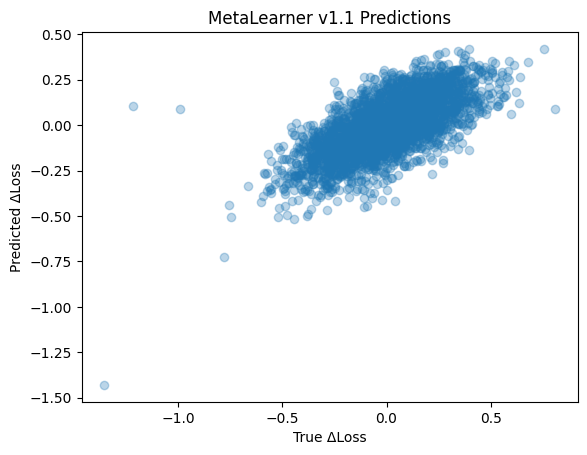

In [15]:
model.eval()
with torch.no_grad():
    preds = model(X_val.to(device)).cpu().numpy()

import matplotlib.pyplot as plt
plt.scatter(y_val.numpy(), preds, alpha=0.3)
plt.xlabel("True ΔLoss")
plt.ylabel("Predicted ΔLoss")
plt.title("MetaLearner v1.1 Predictions")
plt.show()

In [16]:
# Save model weights
torch.save(model.state_dict(), "meta_learner_v1_1.pt")

print("Model saved as meta_learner_v1_1.pt")

Model saved as meta_learner_v1_1.pt


In [17]:
import joblib

joblib.dump(scaler, "meta_scaler_v1_1.pkl")

print("Scaler saved as meta_scaler_v1_1.pkl")

Scaler saved as meta_scaler_v1_1.pkl


In [18]:
from google.colab import files

files.download("meta_dataset_v1_1_raw.csv")
files.download("meta_learner_v1_1.pt")
files.download("meta_scaler_v1_1.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import zipfile

with zipfile.ZipFile("meta_v1_1_bundle.zip", "w") as z:
    z.write("meta_dataset_v1_1_raw.csv")
    z.write("meta_learner_v1_1.pt")
    z.write("meta_scaler_v1_1.pkl")

files.download("meta_v1_1_bundle.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Testing-sanity.**

**then 3000 steps test.**

In [20]:
import joblib
import torch
import numpy as np

# Load scaler
scaler_meta = joblib.load("meta_scaler_v1_1.pkl")

# Rebuild model
class MetaLearnerV11(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

feature_dim = 10
meta_model = MetaLearnerV11(feature_dim)
meta_model.load_state_dict(torch.load("meta_learner_v1_1.pt"))
meta_model.to(device)
meta_model.eval()

print("MetaLearner v1.1 loaded.")

MetaLearner v1.1 loaded.


In [22]:
def run_meta_controlled_test(max_steps=1500):

    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_model.config.pad_token_id = tokenizer.eos_token_id
    gpt_model.to(device)
    gpt_model.train()

    base_lr = 3e-5
    optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=base_lr)

    alpha = 0.2
    min_lr = 1e-6
    max_lr = 1e-4

    ema_multiplier = 1.0
    ema_beta = 0.9

    step = 0
    prev_loss = None

    loss_history = []
    lr_history = []

    for batch in train_dataloader:

        if step >= max_steps:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = gpt_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"]
        )

        loss = outputs.loss
        loss.backward()

        raw_loss = loss.item()
        grad_norm = global_grad_norm(gpt_model)
        weight_norm = global_weight_norm(gpt_model)
        lr_current = optimizer.param_groups[0]["lr"]
        update_ratio = (lr_current * grad_norm) / (weight_norm + 1e-9)
        layer_mean, layer_std = layer_grad_stats(gpt_model)

        delta_loss = 0 if prev_loss is None else raw_loss - prev_loss
        prev_loss = raw_loss

        step_fraction = step / max_steps

        # Build state
        state = np.array([[
            raw_loss,
            delta_loss,
            lr_current,
            grad_norm,
            update_ratio,
            layer_mean,
            layer_std,
            base_lr,
            0,  # constant schedule
            step_fraction
        ]])

        state = np.nan_to_num(state, nan=0.0, posinf=0.0, neginf=0.0)
        state_scaled = scaler_meta.transform(state)

        state_tensor = torch.tensor(state_scaled, dtype=torch.float32).to(device)

        with torch.no_grad():
            pred_delta = meta_model(state_tensor)

        multiplier = 1 - alpha * torch.tanh(pred_delta)
        multiplier = torch.clamp(multiplier, 0.9, 1.1)

        # EMA smoothing
        ema_multiplier = ema_beta * ema_multiplier + (1 - ema_beta) * multiplier.item()

        new_lr = lr_current * ema_multiplier
        new_lr = max(min_lr, min(max_lr, new_lr))

        optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()
        optimizer.zero_grad()

        loss_history.append(raw_loss)
        lr_history.append(new_lr)

        step += 1

    return loss_history, lr_history

In [23]:
def run_baseline_test(max_steps=1500):

    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_model.config.pad_token_id = tokenizer.eos_token_id
    gpt_model.to(device)
    gpt_model.train()

    optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=3e-5)

    step = 0
    loss_history = []

    for batch in train_dataloader:

        if step >= max_steps:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = gpt_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"]
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        step += 1

    return loss_history

In [24]:
baseline_loss = run_baseline_test()
controlled_loss, controlled_lr = run_meta_controlled_test()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


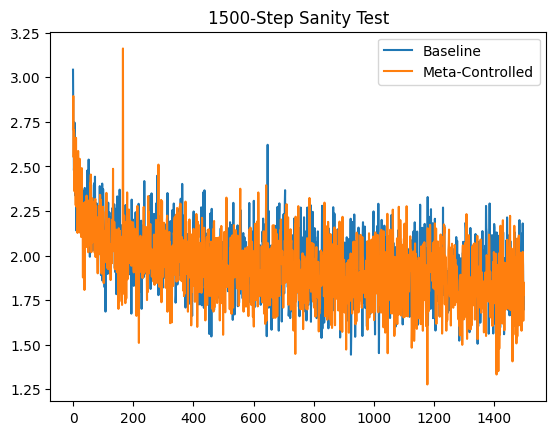

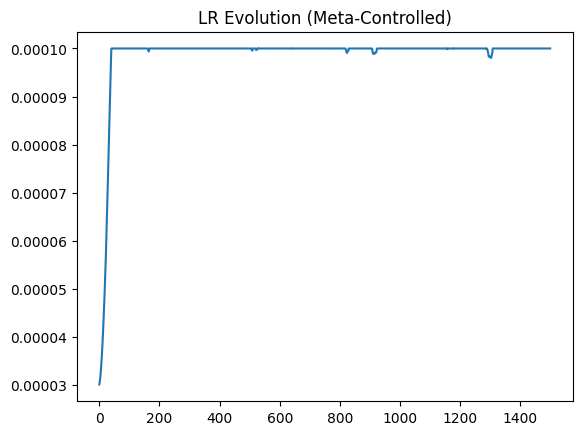

In [25]:
import matplotlib.pyplot as plt

plt.plot(baseline_loss, label="Baseline")
plt.plot(controlled_loss, label="Meta-Controlled")
plt.legend()
plt.title("1500-Step Sanity Test")
plt.show()

plt.plot(controlled_lr)
plt.title("LR Evolution (Meta-Controlled)")
plt.show()

In [26]:
def run_meta_controlled_test(max_steps=1500):

    import torch
    import numpy as np

    # Fresh GPT-2
    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_model.config.pad_token_id = tokenizer.eos_token_id
    gpt_model.to(device)
    gpt_model.train()

    base_lr = 3e-5
    optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=base_lr)

    # ---- Controller Hyperparams ----
    alpha = 0.2
    min_lr = 1e-6
    max_lr = 1e-4
    ema_beta = 0.9
    warmup_steps = 50

    step = 0
    prev_loss = None

    loss_history = []
    lr_history = []

    for batch in train_dataloader:

        if step >= max_steps:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = gpt_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"]
        )

        loss = outputs.loss
        loss.backward()

        # ---- Stability Guard ----
        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), 1.0)

        raw_loss = loss.item()
        grad_norm = global_grad_norm(gpt_model)
        weight_norm = global_weight_norm(gpt_model)

        lr_current = optimizer.param_groups[0]["lr"]
        update_ratio = (lr_current * grad_norm) / (weight_norm + 1e-9)
        layer_mean, layer_std = layer_grad_stats(gpt_model)

        delta_loss = 0.0 if prev_loss is None else raw_loss - prev_loss
        prev_loss = raw_loss

        step_fraction = step / max_steps

        # ---- Build State ----
        state = np.array([[
            raw_loss,
            delta_loss,
            lr_current,
            grad_norm,
            update_ratio,
            layer_mean,
            layer_std,
            base_lr,
            0,  # constant schedule
            step_fraction
        ]])

        state = np.nan_to_num(state, nan=0.0, posinf=0.0, neginf=0.0)
        state_scaled = scaler_meta.transform(state)
        state_tensor = torch.tensor(state_scaled, dtype=torch.float32).to(device)

        # ---- Meta Prediction ----
        with torch.no_grad():
            pred_delta = meta_model(state_tensor)

        # ---- Multiplier ----
        multiplier = 1 - alpha * torch.tanh(pred_delta)
        multiplier = torch.clamp(multiplier, 0.9, 1.1)

        # ---- Smooth Current Step Only (NO compounding) ----
        smoothed_multiplier = ema_beta * 1.0 + (1 - ema_beta) * multiplier.item()

        # ---- Warmup Lock ----
        if step < warmup_steps:
            smoothed_multiplier = 1.0

        new_lr = lr_current * smoothed_multiplier
        new_lr = max(min_lr, min(max_lr, new_lr))

        optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()
        optimizer.zero_grad()

        loss_history.append(raw_loss)
        lr_history.append(new_lr)

        step += 1

    return loss_history, lr_history

In [27]:
def run_baseline_test(max_steps=1500):

    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_model.config.pad_token_id = tokenizer.eos_token_id
    gpt_model.to(device)
    gpt_model.train()

    optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=3e-5)

    step = 0
    loss_history = []

    for batch in train_dataloader:

        if step >= max_steps:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = gpt_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"]
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), 1.0)

        optimizer.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        step += 1

    return loss_history

In [28]:
baseline_loss = run_baseline_test()
controlled_loss, controlled_lr = run_meta_controlled_test()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


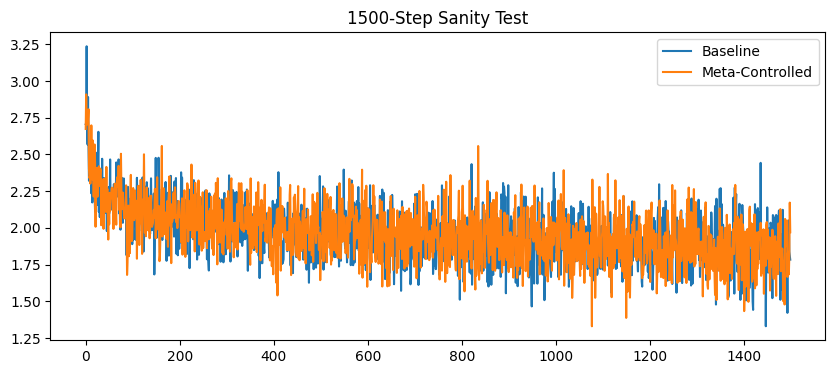

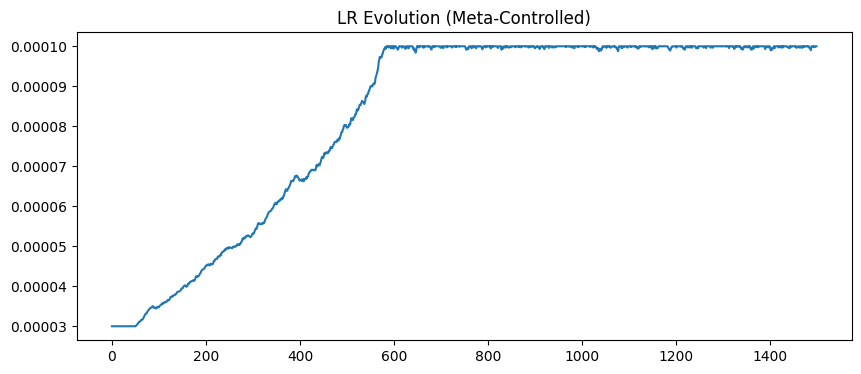

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(baseline_loss, label="Baseline")
plt.plot(controlled_loss, label="Meta-Controlled")
plt.legend()
plt.title("1500-Step Sanity Test")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(controlled_lr)
plt.title("LR Evolution (Meta-Controlled)")
plt.show()